# Détection de Contours et Segmentation Non-Supervisée
Exploration des filtres classiques (Canny, Sobel) et des seuillages (Otsu) avec `scikit-image`.

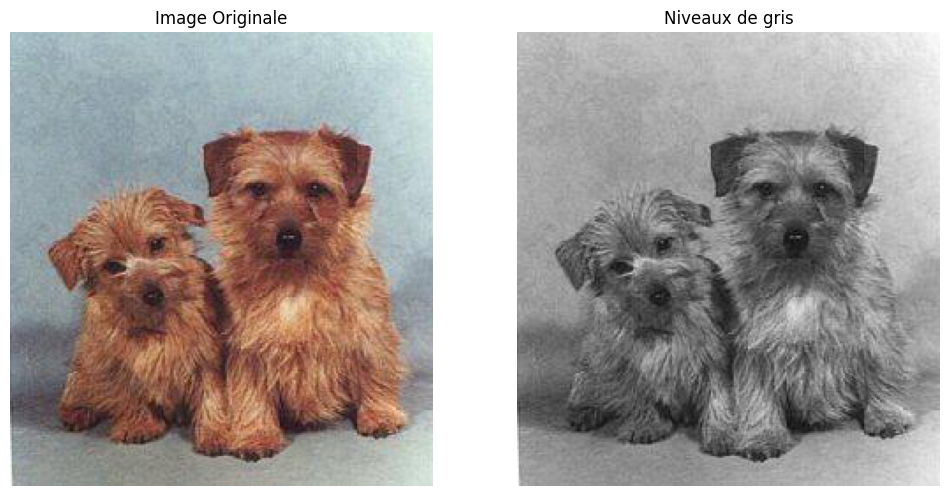

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, measure, morphology

# Charger une image d'exemple
data_dir = '../data/stanford_dogs/Images'
image_paths = glob.glob(os.path.join(data_dir, '*/*.jpg'))
if not image_paths:
    print('Veuillez télécharger le dataset d\'abord.')
else:
    # Prendre une image au hasard ou la première
    sample_path = image_paths[15] # Index arbitraire
    img_rgb = io.imread(sample_path)
    img_gray = color.rgb2gray(img_rgb)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img_rgb); ax[0].set_title('Image Originale'); ax[0].axis('off')
    ax[1].imshow(img_gray, cmap='gray'); ax[1].set_title('Niveaux de gris'); ax[1].axis('off')
    plt.show()

## 1. Seuillage Global (Otsu)
Le filtre d'Otsu trouve automatiquement le seuil optimal pour séparer l'image en deux classes (fond / objet) en se basant sur l'histogramme des niveaux de gris.

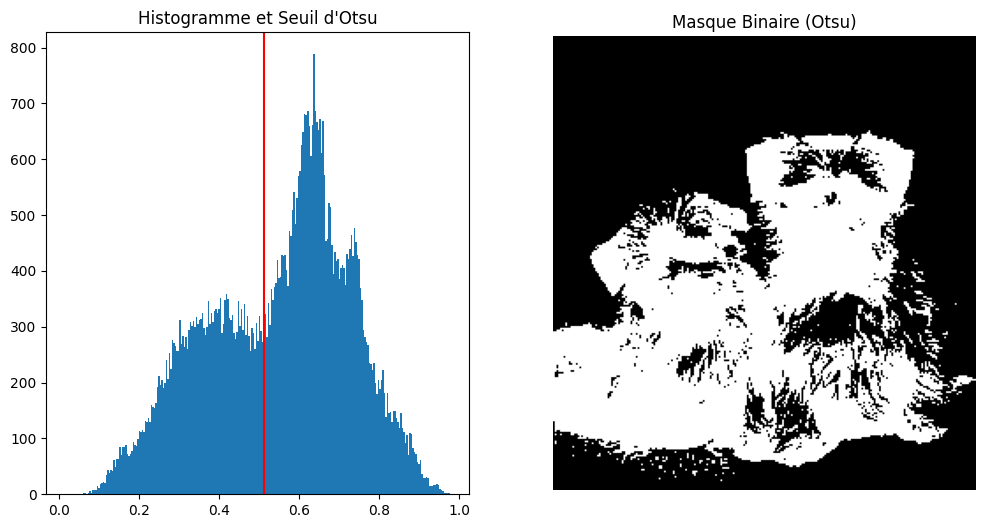

In [2]:
if image_paths:
    threshold = filters.threshold_otsu(img_gray)
    binary_mask = img_gray < threshold # Les chiens sont souvent plus sombres ou plus clairs selon le fond
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].hist(img_gray.ravel(), bins=256)
    ax[0].axvline(threshold, color='r')
    ax[0].set_title('Histogramme et Seuil d\'Otsu')
    
    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title('Masque Binaire (Otsu)')
    ax[1].axis('off')
    plt.show()

## 2. Détection de Gradients (Sobel)
Le filtre de Sobel met en évidence les variations de forte intensité (les contours) en calculant le gradient spatial de l'image.

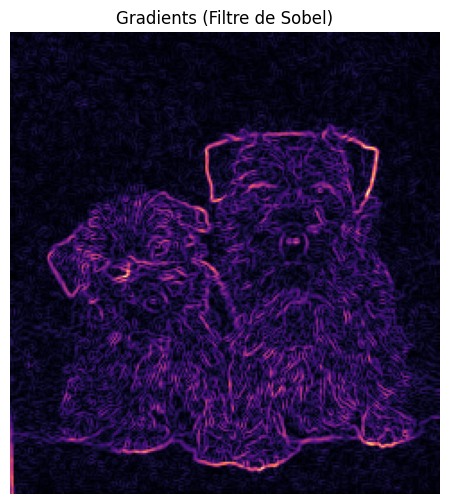

In [3]:
if image_paths:
    edges_sobel = filters.sobel(img_gray)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(edges_sobel, cmap='magma')
    plt.title('Gradients (Filtre de Sobel)')
    plt.axis('off')
    plt.show()

## 3. Détection de Contours Avancée (Canny)
L'algorithme de Canny est le détecteur de contours le plus populaire. Il utilise un filtrage Gaussien, puis un calcul de gradient, et enfin une hystérésis pour ne retenir que les contours les plus pertinents.

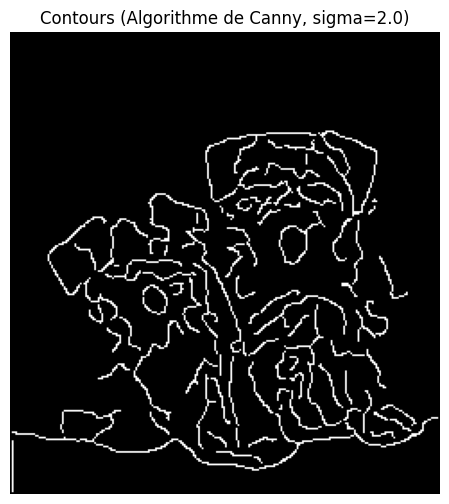

In [4]:
if image_paths:
    # sigma gère la force du flou Gaussien (plus grand = moins de bruit mais contours moins nets)
    edges_canny = feature.canny(img_gray, sigma=2.0)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(edges_canny, cmap='gray')
    plt.title('Contours (Algorithme de Canny, sigma=2.0)')
    plt.axis('off')
    plt.show()

## 4. Combinaison & Morphologie Mathématique
Souvent on combine un détecteur de contour avec une fermeture morphologique (Morphological closing) pour combler les trous et obtenir un masque de segmentation continu.

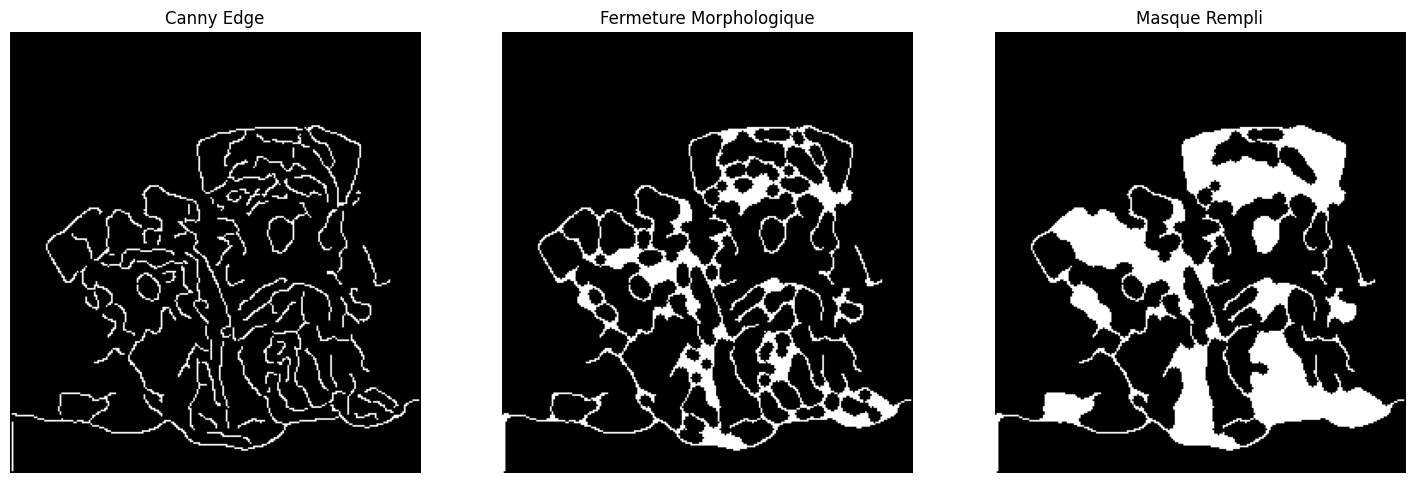

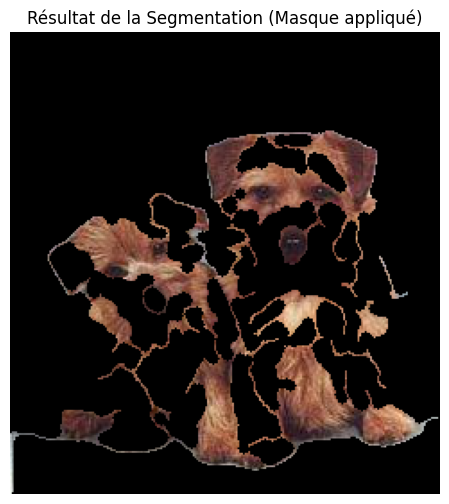

In [5]:
if image_paths:
    # Dilatation puis érosion pour fermer les contours de Canny
    closed_edges = morphology.closing(edges_canny, morphology.disk(3))
    # Remplissage des trous à l'intérieur du contour fermé
    filled_mask = morphology.remove_small_holes(closed_edges, area_threshold=500)
    
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(edges_canny, cmap='gray'); ax[0].set_title('Canny Edge'); ax[0].axis('off')
    ax[1].imshow(closed_edges, cmap='gray'); ax[1].set_title('Fermeture Morphologique'); ax[1].axis('off')
    ax[2].imshow(filled_mask, cmap='gray'); ax[2].set_title('Masque Rempli'); ax[2].axis('off')
    plt.show()
    
    # Appliquer le masque sur l'image originale
    segmented_img = img_rgb.copy()
    segmented_img[~filled_mask] = 0
    
    plt.figure(figsize=(8,6))
    plt.imshow(segmented_img)
    plt.title('Résultat de la Segmentation (Masque appliqué)')
    plt.axis('off')
    plt.show()